# Problem Statement



<html> <font color = Darkblue>
The purpose is to predict whether the Pima Indian women shows signs of diabetes or not. We are using a dataset collected by "National Institute of Diabetes and Digestive and Kidney Diseases" which consists of a number of attributes which would help us to perform this prediction.
</font>
</html>

<html>
<font color = blue>
<b>Constraints on data collection </b>

</font>
</html>

<html> <font color = Darkblue>
All patients whose data has been collected are females at least 21 years old of Pima Indian heritage
</font>
</html>

In [38]:
#Import all the necessary modules
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve, auc
from sklearn import metrics

In [39]:
# importing ploting libraries
import matplotlib.pyplot as plt   
#importing seaborn for statistical plots
import seaborn as sns
# To enable plotting graphs in Jupyter notebook
%matplotlib inline 

In [59]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

# Q1. Load the PIMA Indian Diabetes file into Python DataFrame. 


The file can be accessed directly from the URL (https://archive.ics.uci.edu/ml/machine-learning-databases/pima-indians-diabetes/pima-indians-diabetes.data or you may first download it to a local folder and then load it into Python dataframe.  Let us assume the data frame is named pima_df


In [40]:
colnames = ['preg', 'glu', 'bp', 'sft', 'ins', 'bmi', 'dpf', 'age', 'class']
pima_df = pd.read_csv("pima-indians-diabetes.data",names=colnames)

It is always a good practice to eye-ball raw data to get a feel of the data in terms of number of structure of the file, number of attributes, types of attributes and a general idea of likely challenges in the dataset. You would notice that it is a comma separated file. There are no column names!. Check the associated folders and find out about each attribute the name. What information is available about the data.

# Q2. Print 10 samples from the dataset

In [41]:
pima_df.head(10)

,preg,glu,bp,sft,ins,bmi,dpf,age,class
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
5,5,116,74,0,0,25.6,0.201,30,0
6,3,78,50,32,88,31.0,0.248,26,1
7,10,115,0,0,0,35.3,0.134,29,0
8,2,197,70,45,543,30.5,0.158,53,1
9,8,125,96,0,0,0.0,0.232,54,1


# Q3 Print the datatypes of each column and the shape of the dataset 

In [42]:
pima_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
preg     768 non-null int64
glu      768 non-null int64
bp       768 non-null int64
sft      768 non-null int64
ins      768 non-null int64
bmi      768 non-null float64
dpf      768 non-null float64
age      768 non-null int64
class    768 non-null int64
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [43]:
pima_df.shape

(768, 9)

There are '0's in the data. Are they really valid '0's or they are missing values?
Plasma, BP, skin thickness etc. these values cannot be 0.
look at column by column logically to understand this.


# Q4 Replace all the 0s in the column with the median of the same column value accordingly.

In [44]:
pima_df.describe()

,preg,glu,bp,sft,ins,bmi,dpf,age,class
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [45]:
#Check the min values of all columns
pima_df.min()

preg      0.000
glu       0.000
bp        0.000
sft       0.000
ins       0.000
bmi       0.000
dpf       0.078
age      21.000
class     0.000
dtype: float64

In [46]:
#Replace all the 0s in the column with the median of the same column value accordingly
for col in ['glu', 'bp', 'sft', 'ins', 'bmi']:
       pima_df[col]=pima_df[col].replace(0, pima_df[col].median())

In [47]:
#Check the min values got updated
pima_df.min()

preg      0.000
glu      44.000
bp       24.000
sft       7.000
ins      14.000
bmi      18.200
dpf       0.078
age      21.000
class     0.000
dtype: float64

# Q5 Print the descriptive statistics of each & every column using describe() function

In [48]:
pima_df.describe()

,preg,glu,bp,sft,ins,bmi,dpf,age,class
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,121.656250,72.386719,27.334635,94.652344,32.450911,0.471876,33.240885,0.348958
std,3.369578,30.438286,12.096642,9.229014,105.547598,6.875366,0.331329,11.760232,0.476951
min,0.000000,44.000000,24.000000,7.000000,14.000000,18.200000,0.078000,21.000000,0.000000
25%,1.000000,99.750000,64.000000,23.000000,30.500000,27.500000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,31.250000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


# Q6 See the distribution of 'Class' variable and plot it using appropriate graph.

In [50]:
pima_df.groupby(["class"]).count()

,preg,glu,bp,sft,ins,bmi,dpf,age
class,,,,,,,,
0,500,500,500,500,500,500,500,500
1,268,268,268,268,268,268,268,268


In [53]:
x = pima_df['class'].value_counts()
x

0    500
1    268
Name: class, dtype: int64

In [14]:
# Most are not diabetic. The ratio is almost 1:2 in favor or class 0.  The model's ability to predict class 0 will 
# be better than predicting class 1. 

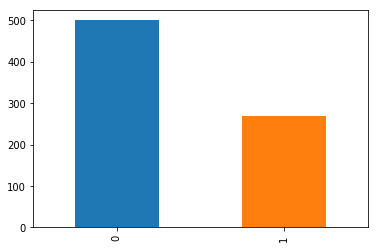

In [55]:
x.plot.bar()

#Just for your understanding - Using univariate analysis check the individual attributes for their basic statistic such as central values, spread, tails etc. What are your observations (any two attributes). Its an optional step and will not be graded.

In [16]:
## TODO Siju

# Q7. Use pairplots and correlation method to observe the relationship between different variables and state your insights.
Hint: Use seaborn plot and check the relationship between different variables 


Using the plot - infer the relationship between different variables

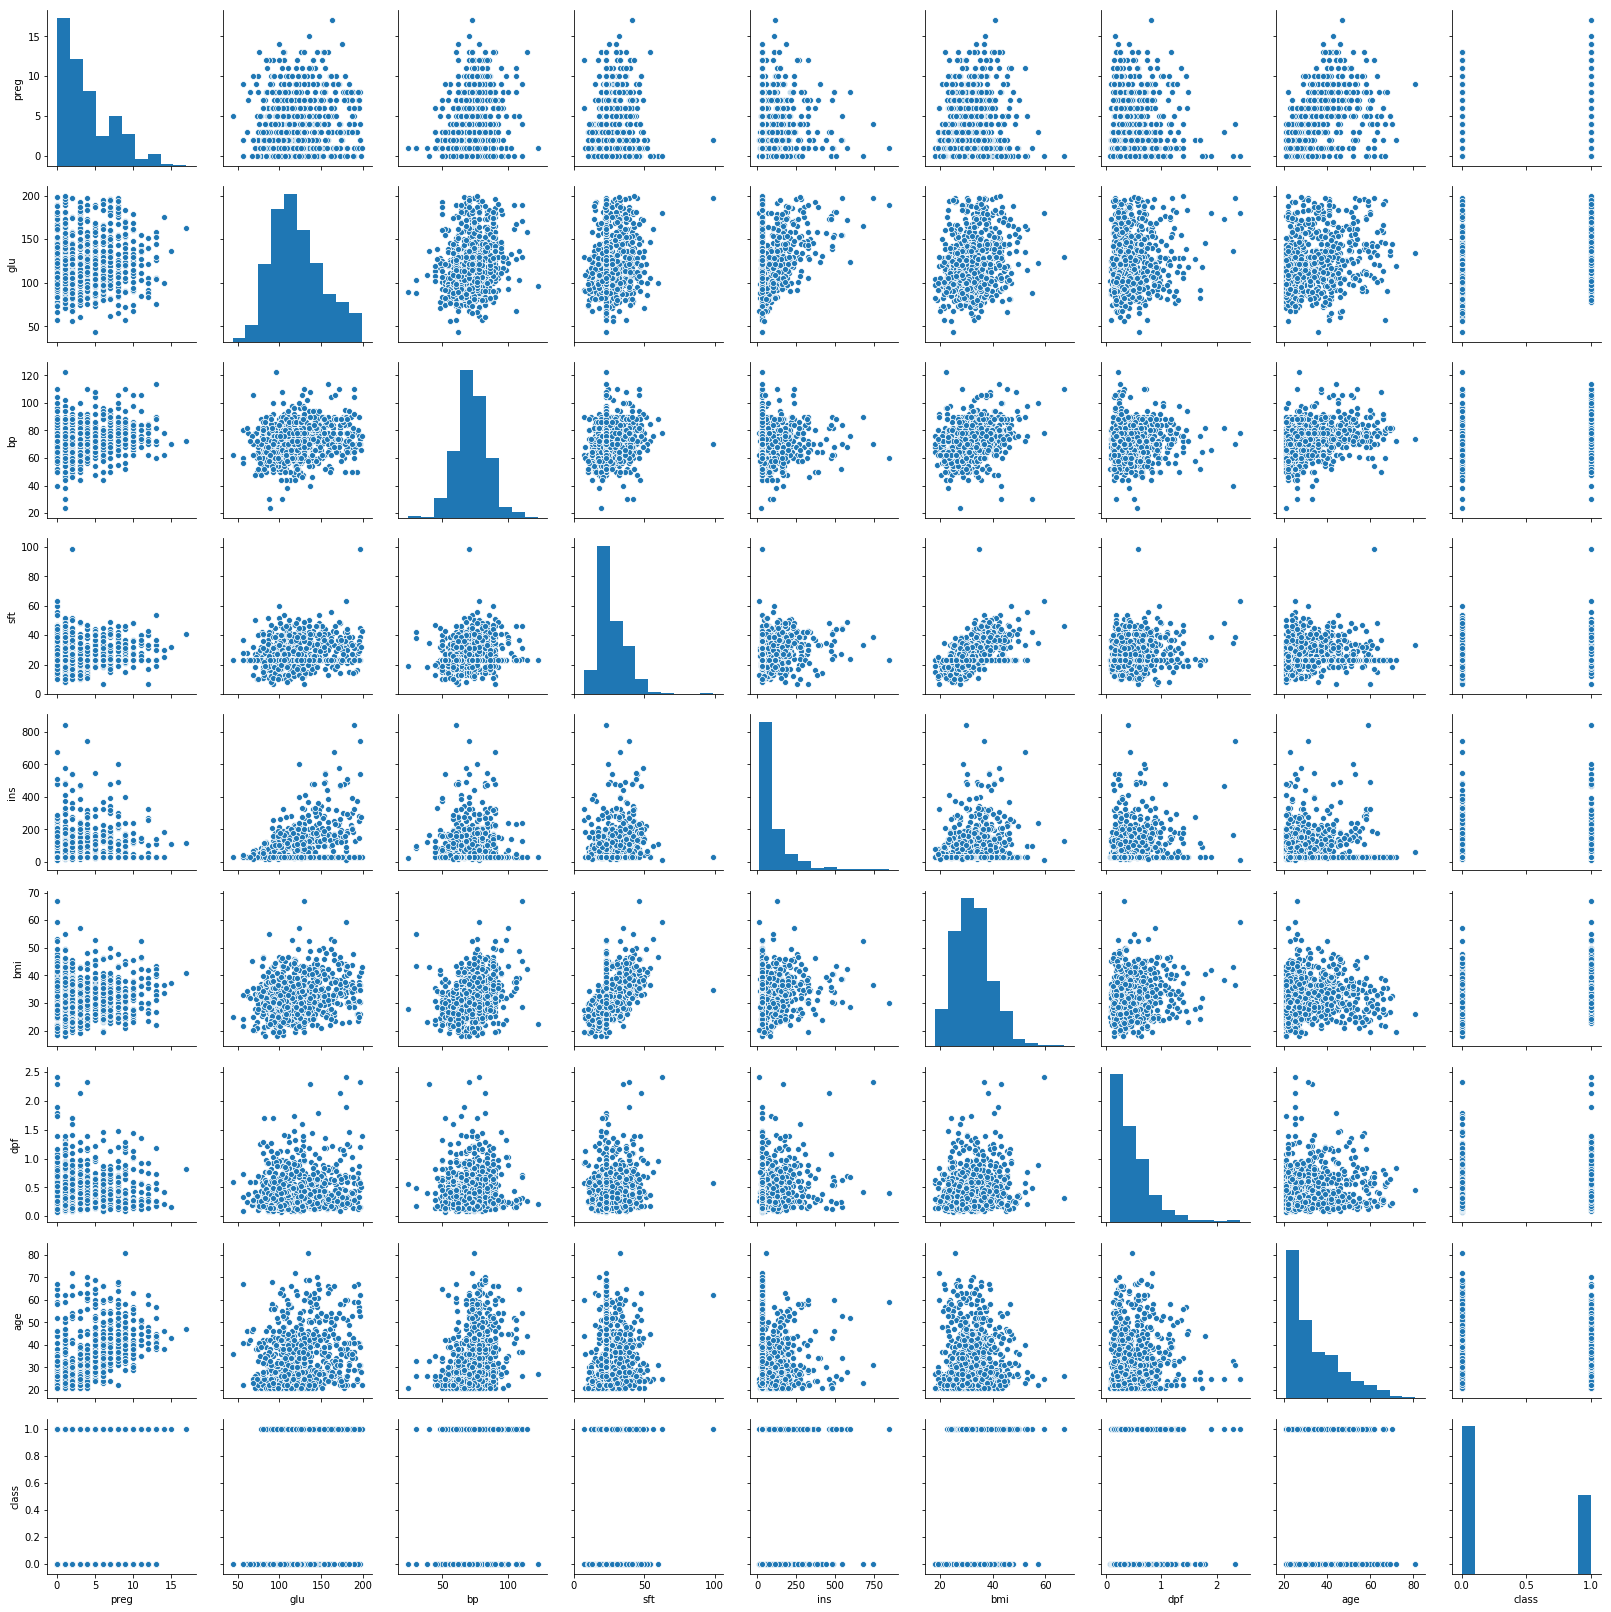

In [17]:
# Pairplot using sns
sns.pairplot(pima_df)

In [18]:
# data for all the attributes are skewed, especially for the variable "ins"
# The mean for ins is 80(rounded) while the median is 30.5 which clearly indicates an extreme long tail on the right
# Attributes which look normally distributed (glu, pres, skin, and mass).
# Some of the attributes look like they may have an exponential distribution (preg, ins, pedi, age).
# Age should probably have a normal distribution, the constraints on the data collection may have skewed the distribution.
# There is no obvious relationship between age and onset of diabetes.
# There is no obvious relationship between dpf function and onset of diabetes.

# Q8 Split the pima_df into training and test set in the ratio of 70:30 (Training:Test).</b>


In [19]:
X =  pima_df.drop("class", axis=1)
y =  pima_df.pop("class")

In [20]:
test_size = 0.30 # taking 70:30 training and test set
seed = 0  # Random numbmer seeding for reapeatability of the code
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=seed)

# Q9 Create the decision tree model using “entropy” method of reducing the entropy and fit it to training data.</b>



In [21]:
from sklearn.tree import DecisionTreeClassifier

In [22]:
Dt_model=DecisionTreeClassifier(criterion='entropy', max_depth=4, random_state=0)#fully grown tree (high bias error and var error)

## A common function to analyze all models

In [23]:
#A common function to analyze all model
def analyze_model(model):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    accuracy = metrics.accuracy_score(y_test, y_pred)
    print("Accuracy = ", accuracy)
    model_score = model.score(X_train, y_train)
    print("Train Accuracy = ", model_score)
    model_score = model.score(X_test, y_test)
    print("Test Accuracy = ", model_score)
    cm = metrics.confusion_matrix(y_test, y_pred)
    print("Confusion Matrix\n", cm)

# Q10 Print the accuracy of the model & print the confusion matrix 

In [24]:
analyze_model(Dt_model)

Accuracy =  0.7445887445887446
Train Accuracy =  0.7877094972067039
Test Accuracy =  0.7445887445887446
Confusion Matrix
 [[127  30]
 [ 29  45]]


Print the feature importance of the decision model - Optional

In [25]:
#TODO Siju

# Q12 Apply the Random forest model and print the accuracy of Random forest Model

In [26]:
from sklearn.ensemble import RandomForestClassifier

/usr/lib/python3/dist-packages/sklearn/ensemble/weight_boosting.py:29: DeprecationWarning: numpy.core.umath_tests is an internal NumPy module and should not be imported. It will be removed in a future NumPy release.
  from numpy.core.umath_tests import inner1d


In [27]:
Rf_model = RandomForestClassifier(n_estimators=51, max_depth=5, criterion='entropy',random_state=0 )

In [28]:
analyze_model(Rf_model)

Accuracy =  0.7705627705627706
Train Accuracy =  0.839851024208566
Test Accuracy =  0.7705627705627706
Confusion Matrix
 [[142  15]
 [ 38  36]]


# Q13 Apply Adaboost Ensemble Algorithm for the same data and print the accuracy.

In [29]:
from sklearn.ensemble import AdaBoostClassifier

In [30]:
Rf_model = RandomForestClassifier(n_estimators=51, max_depth=5, criterion='entropy',random_state=0 )
boost_RF_model = AdaBoostClassifier(base_estimator=Rf_model, n_estimators=Rf_model.n_estimators, random_state=0)

In [31]:
analyze_model(boost_RF_model)

Accuracy =  0.7922077922077922
Train Accuracy =  1.0
Test Accuracy =  0.7922077922077922
Confusion Matrix
 [[137  20]
 [ 28  46]]


# Q14 - Apply Bagging Classifier Algorithm and print the accuracy.

In [32]:
from sklearn.ensemble import BaggingClassifier
Dt_model=DecisionTreeClassifier(criterion='entropy', max_depth=5, random_state=0)
bag_dt_model = BaggingClassifier(base_estimator=Dt_model, n_estimators=51,random_state=0)

In [33]:
analyze_model(bag_dt_model)

Accuracy =  0.7705627705627706
Train Accuracy =  0.8547486033519553
Test Accuracy =  0.7705627705627706
Confusion Matrix
 [[139  18]
 [ 35  39]]


# Q15 - Apply GradientBoost Classifier Algorithm for the same data and print the accuracy

In [34]:
from sklearn.ensemble import GradientBoostingClassifier

In [35]:
gboost = GradientBoostingClassifier(n_estimators=100,random_state=0)

In [36]:
analyze_model(gboost)

Accuracy =  0.7705627705627706
Train Accuracy =  0.9329608938547486
Test Accuracy =  0.7705627705627706
Confusion Matrix
 [[135  22]
 [ 31  43]]


# Next steps are optional and will not be graded.

Voting is one of the simplest ways of combining the predictions from multiple machine learning algorithms.

It works by first creating two or more standalone models from your training dataset. A Voting Classifier can then be used to wrap your models and average the predictions of the sub-models when asked to make predictions for new data.

Apply Voting Classfier on the given dataset and state your insights.

In [56]:
from sklearn.ensemble import VotingClassifier

In [57]:
stacked = VotingClassifier(estimators = [('GradientBoosted',gboost),
                                         ('Bagged_dt', bag_dt_model), 
                                         ('Boosted_RF', boost_RF_model)], voting='soft')

In [60]:
analyze_model(stacked)

/usr/lib/python3/dist-packages/sklearn/preprocessing/label.py:151: DeprecationWarning: The truth value of an empty array is ambiguous. Returning False, but in future this will result in an error. Use `array.size > 0` to check that an array is not empty.
  if diff:


Accuracy =  0.7965367965367965
Train Accuracy =  0.9348230912476723
Test Accuracy =  0.7965367965367965
Confusion Matrix
 [[141  16]
 [ 31  43]]


/usr/lib/python3/dist-packages/sklearn/preprocessing/label.py:151: DeprecationWarning: The truth value of an empty array is ambiguous. Returning False, but in future this will result in an error. Use `array.size > 0` to check that an array is not empty.
  if diff:
/usr/lib/python3/dist-packages/sklearn/preprocessing/label.py:151: DeprecationWarning: The truth value of an empty array is ambiguous. Returning False, but in future this will result in an error. Use `array.size > 0` to check that an array is not empty.
  if diff:
